
Subsystem information
Number of subsystems = 15
 1: (3, 4, 5, 6)
 2: (3, 4, 5, 7)
 3: (3, 4, 5, 8)
 4: (3, 4, 6, 7)
 5: (3, 4, 6, 8)
 6: (3, 4, 7, 8)
 7: (3, 5, 6, 7)
 8: (3, 5, 6, 8)
 9: (3, 5, 7, 8)
10: (3, 6, 7, 8)
11: (4, 5, 6, 7)
12: (4, 5, 6, 8)
13: (4, 5, 7, 8)
14: (4, 6, 7, 8)
15: (5, 6, 7, 8)

Building many-body spin operators...

Building power-law XY Hamiltonian...

U(1) symmetry check
|| [H,Q] || = 0.0

Charge-sector projector check
|| sum_q Pi_q - I_A || = 0.0

Charge sectors:
q = -2.0, dimension = 1
q = -1.0, dimension = 4
q = +0.0, dimension = 6
q = +1.0, dimension = 4
q = +2.0, dimension = 1

Simulating theta/pi = 0.20
Average initial EA = 0.6350037129382871

Simulating theta/pi = 0.33
Average initial EA = 1.1168198493238282

Simulating theta/pi = 0.50
Average initial EA = 1.2966822024302036

Initial averaged EA
theta/pi = 0.20    Delta S_A(0) = 0.63500371
theta/pi = 0.33    Delta S_A(0) = 1.11681985
theta/pi = 0.50    Delta S_A(0) = 1.29668220


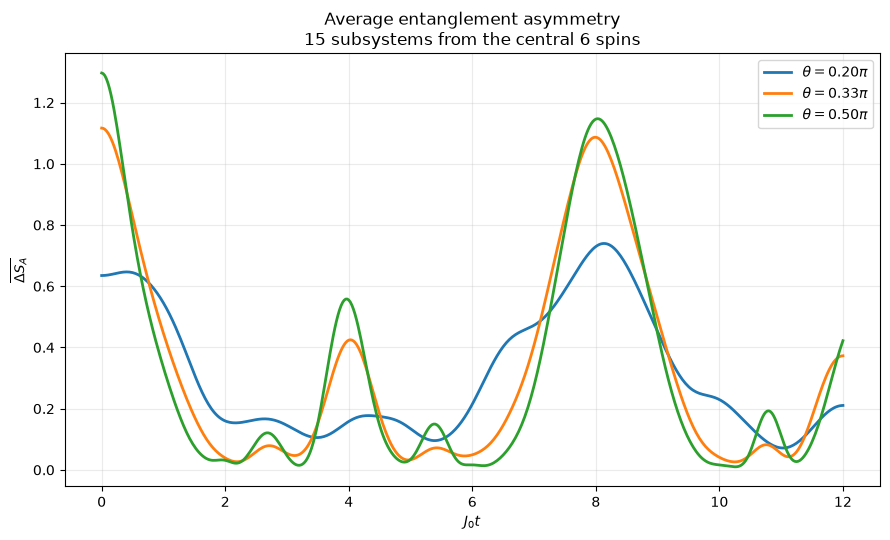

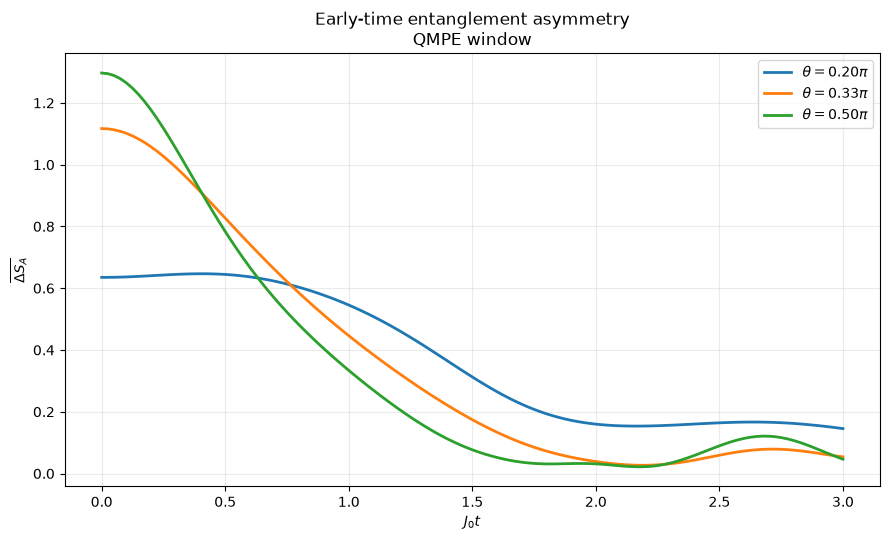


QMPE analysis
D(0) = 0.6616784894919165
QMPE analysis window:
0 <= J0*t <= 3.0
Robust first crossing = 0.6327367747528355
Early-time QMPE strength M = 0.2591925193361744

Robust early-time QMPE detected.


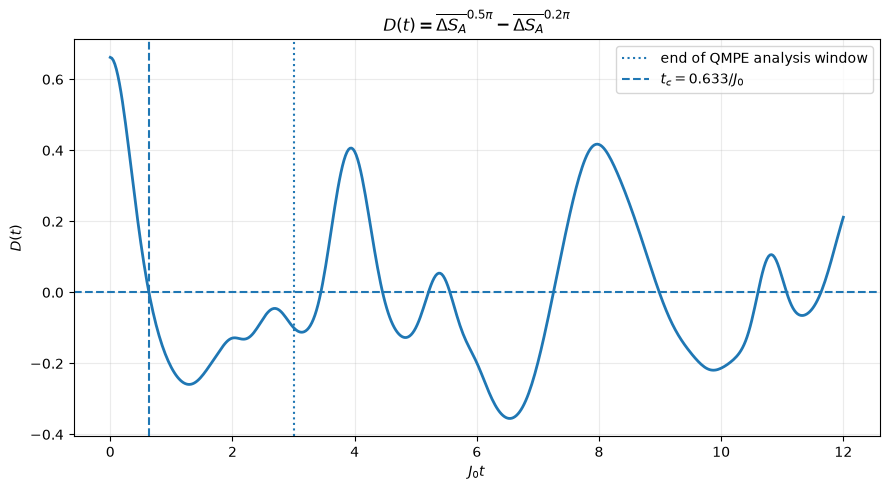

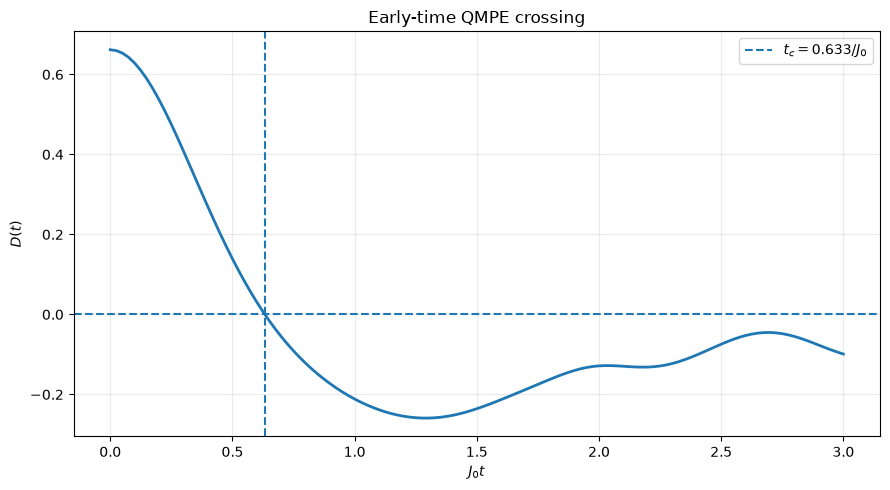

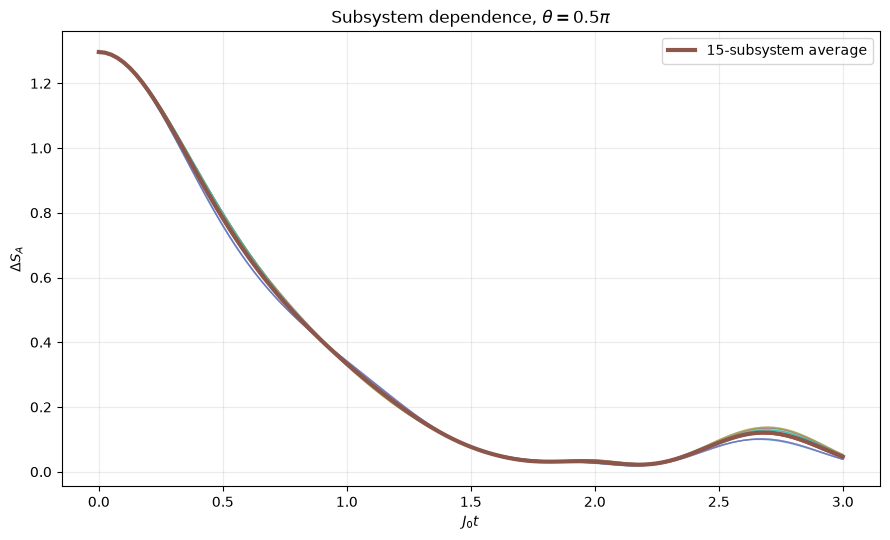

In [2]:
# ============================================================
# STAGE I
# Quantum Mpemba Effect in a power-law long-range XY chain
#
# Goal:
#   Reproduce the basic physics of Fig. 1(b) in
#
#   "Observing the Quantum Mpemba Effect in Quantum Simulations"
#
#
# Main observable:
#
#       Delta S_A
#
#         = log[Tr(rho_A^2)]
#
#           - log[Tr(rho_A,Q^2)]
#
#
# where
#
#       rho_A,Q = sum_q Pi_q rho_A Pi_q
#
#
# IMPORTANT:
#
# 1. No von Neumann entropy is used.
#
# 2. EA is averaged over all 4-spin subsystems selected
#    from the central 6 spins:
#
#       C(6,4) = 15 subsystems.
#
# 3. QMPE is detected only in an early-time window,
#    so late finite-size revivals are not counted as
#    independent QMPE crossings.
#
# ============================================================


import numpy as np
import matplotlib.pyplot as plt

from itertools import combinations

from qutip import (
    basis,
    tensor,
    qeye,
    sigmax,
    sigmay,
    sigmaz,
    sesolve,
)


# ============================================================
# 0. GLOBAL PARAMETERS
# ============================================================

# Total number of spins
N = 12


# ------------------------------------------------------------
# Interaction scale
#
# We use dimensionless units:
#
#       J0 = 1
#
# Therefore the horizontal axis is
#
#       tau = J0 * t
#
# ------------------------------------------------------------

J0 = 1.0


# ------------------------------------------------------------
# Power-law exponent
#
# Paper-like value:
#
#       alpha ~ 1
#
# ------------------------------------------------------------

alpha = 1.0


# ------------------------------------------------------------
# Tilt angles
#
# Same three values used in the paper
# ------------------------------------------------------------

thetas = [
    0.20 * np.pi,
    0.33 * np.pi,
    0.50 * np.pi,
]


# ------------------------------------------------------------
# Full simulation time
#
# We intentionally simulate longer than the QMPE window
# so that finite-size oscillations can also be seen.
# ------------------------------------------------------------

t_max = 12.0

Nt = 481

tlist = np.linspace(
    0.0,
    t_max,
    Nt
)


# ------------------------------------------------------------
# EARLY-TIME WINDOW
#
# Only this region is used to quantify QMPE.
#
# This avoids interpreting late finite-size revivals as
# new Mpemba crossings.
#
# You can later test:
#
#       2.0, 2.5, 3.0, 4.0
#
# for robustness.
# ------------------------------------------------------------

t_qmpe_max = 3.0


# ------------------------------------------------------------
# Crossing robustness parameters
#
# After crossing, D(t) must become smaller than
#
#       -crossing_epsilon
#
# for several consecutive time points.
#
# This prevents tiny numerical zero crossings from being
# classified as QMPE.
# ------------------------------------------------------------

crossing_epsilon = 1e-3

min_negative_points = 5


# ============================================================
# 1. DEFINE CENTRAL 6 SPINS
# ============================================================

# Paper:
#
#       ion numbers 4,5,6,7,8,9
#
# Python indexing:
#
#       3,4,5,6,7,8
#
# ============================================================

central_sites = [
    3,
    4,
    5,
    6,
    7,
    8,
]


# ------------------------------------------------------------
# Subsystem size
# ------------------------------------------------------------

NA = 4


# ------------------------------------------------------------
# Generate ALL 4-spin subsystems from central 6 spins
#
# Number:
#
#       C(6,4) = 15
#
# Includes both connected and disconnected subsystems.
# ------------------------------------------------------------

subsystems = list(
    combinations(
        central_sites,
        NA
    )
)


print()
print("========================================")
print("Subsystem information")
print("========================================")

print(
    "Number of subsystems =",
    len(subsystems)
)

for index, A in enumerate(subsystems):

    print(
        f"{index + 1:2d}: {A}"
    )


# ============================================================
# 2. SINGLE-SPIN OPERATORS
# ============================================================

sx = sigmax()

sy = sigmay()

sz = sigmaz()

I2 = qeye(2)


# ============================================================
# 3. EMBED A SINGLE-SPIN OPERATOR INTO FULL HILBERT SPACE
# ============================================================

def local_operator(
    op,
    site,
    N
):

    ops = [
        I2
        for _ in range(N)
    ]

    ops[site] = op

    return tensor(ops)


# ============================================================
# 4. BUILD MANY-BODY SPIN OPERATORS
# ============================================================

print()
print("Building many-body spin operators...")


Sx = [
    local_operator(
        sx,
        i,
        N
    )
    for i in range(N)
]


Sy = [
    local_operator(
        sy,
        i,
        N
    )
    for i in range(N)
]


Sz = [
    local_operator(
        sz,
        i,
        N
    )
    for i in range(N)
]


# ============================================================
# 5. TOTAL U(1) CHARGE
#
#
#       Q
#
#         =
#
#       1/2 sum_i sigma_i^z
#
#
# ============================================================

Q_total = 0


for i in range(N):

    Q_total += (
        0.5 * Sz[i]
    )


# ============================================================
# 6. POWER-LAW XY HAMILTONIAN
#
#
#                 J0
#       J_ij = ----------
#              |i-j|^alpha
#
#
#
#       H_XY
#
#          =
#
#       sum_{i<j}
#
#       J_ij / 2
#
#       * (
#
#           sigma_x^i sigma_x^j
#
#             +
#
#           sigma_y^i sigma_y^j
#
#         )
#
#
# ============================================================

def build_powerlaw_XY(
    N,
    J0,
    alpha,
    Sx,
    Sy
):

    H = 0


    for i in range(N):

        for j in range(
            i + 1,
            N
        ):

            distance = (
                j - i
            )


            Jij = (
                J0
                /
                distance ** alpha
            )


            H += (

                0.5

                * Jij

                * (

                    Sx[i] * Sx[j]

                    +

                    Sy[i] * Sy[j]

                )

            )


    return H


# ============================================================
# 7. BUILD HAMILTONIAN
# ============================================================

print()
print("Building power-law XY Hamiltonian...")


H = build_powerlaw_XY(
    N=N,
    J0=J0,
    alpha=alpha,
    Sx=Sx,
    Sy=Sy
)


# ============================================================
# 8. VERIFY U(1) SYMMETRY
#
#
#       [H,Q] = 0
#
#
# ============================================================

commutator = (

    H * Q_total

    -

    Q_total * H

)


comm_norm = (
    commutator.norm()
)


print()
print("========================================")
print("U(1) symmetry check")
print("========================================")

print(
    "|| [H,Q] || =",
    comm_norm
)


# ============================================================
# 9. DEFINE SPIN BASIS
#
#
#       |up>   = |0>
#
#       |down> = |1>
#
#
# Therefore
#
#       sigma_z |up>   = + |up>
#
#       sigma_z |down> = - |down>
#
#
# ============================================================

up = basis(
    2,
    0
)

down = basis(
    2,
    1
)


# ============================================================
# 10. TILTED FERROMAGNETIC INITIAL STATE
#
#
# Single spin:
#
#
#       |psi_theta>
#
#          =
#
#       cos(theta/2)|down>
#
#          +
#
#       sin(theta/2)|up>
#
#
#
# Full chain:
#
#
#       |Psi_theta>
#
#          =
#
#       |psi_theta> tensor ... tensor |psi_theta>
#
#
# ============================================================

def tilted_product_state(
    theta,
    N
):

    psi_single = (

        np.cos(
            theta / 2.0
        )

        * down

        +

        np.sin(
            theta / 2.0
        )

        * up

    )


    psi0 = tensor(

        [
            psi_single
            for _ in range(N)
        ]

    )


    return psi0.unit()


# ============================================================
# 11. BUILD CHARGE-SECTOR PROJECTORS
#
#
# Subsystem charge:
#
#
#       Q_A
#
#         =
#
#       1/2 sum_{i in A} sigma_i^z
#
#
#
# For NA = 4:
#
#
#       n_up = 0  -> q = -2
#
#       n_up = 1  -> q = -1
#
#       n_up = 2  -> q =  0
#
#       n_up = 3  -> q = +1
#
#       n_up = 4  -> q = +2
#
#
#
# Sector dimensions:
#
#
#       1, 4, 6, 4, 1
#
#
# ============================================================

def build_charge_projectors(
    NA
):

    projectors = {}


    for n_up in range(
        NA + 1
    ):

        q = (
            n_up
            -
            NA / 2.0
        )


        Pq = None


        for up_sites in combinations(
            range(NA),
            n_up
        ):

            state_list = []


            for i in range(NA):

                if i in up_sites:

                    state_list.append(
                        up
                    )

                else:

                    state_list.append(
                        down
                    )


            ket = tensor(
                state_list
            )


            projector = (
                ket
                *
                ket.dag()
            )


            if Pq is None:

                Pq = projector

            else:

                Pq += projector


        projectors[q] = Pq


    return projectors


# ============================================================
# 12. CONSTRUCT PROJECTORS
# ============================================================

charge_projectors = (
    build_charge_projectors(
        NA
    )
)


# ============================================================
# 13. VERIFY PROJECTORS
#
#
#       sum_q Pi_q = I_A
#
#
# ============================================================

Psum = 0


for Pq in charge_projectors.values():

    Psum += Pq


IA = tensor(

    [
        I2
        for _ in range(NA)
    ]

)


projector_error = (
    Psum - IA
).norm()


print()
print("========================================")
print("Charge-sector projector check")
print("========================================")

print(
    "|| sum_q Pi_q - I_A || =",
    projector_error
)


print()
print("Charge sectors:")


for q, Pq in charge_projectors.items():

    print(

        f"q = {q:+.1f}, "

        f"dimension = "
        f"{np.real(Pq.tr()):.0f}"

    )


# ============================================================
# 14. CHARGE SYMMETRIZATION
#
#
# Paper:
#
#
#       rho_A,Q
#
#          =
#
#       sum_q
#
#       Pi_q rho_A Pi_q
#
#
#
# This removes ONLY coherence between different
# charge sectors.
#
#
# ============================================================

def charge_symmetrized_state(
    rho_A,
    projectors
):

    rho_A_Q = (
        0 * rho_A
    )


    for Pq in projectors.values():

        rho_A_Q += (

            Pq

            * rho_A

            * Pq

        )


    return rho_A_Q


# ============================================================
# 15. ENTANGLEMENT ASYMMETRY
#
#
# EXACTLY PAPER Eq. (1):
#
#
#       Delta S_A
#
#          =
#
#       log[Tr(rho_A^2)]
#
#          -
#
#       log[Tr(rho_A,Q^2)]
#
#
# ============================================================

def entanglement_asymmetry(
    rho_A,
    projectors
):

    rho_A_Q = (
        charge_symmetrized_state(
            rho_A,
            projectors
        )
    )


    # --------------------------------------------------------
    # Original reduced-state purity
    #
    #       P_A = Tr(rho_A^2)
    # --------------------------------------------------------

    purity_A = np.real(

        (
            rho_A
            *
            rho_A
        ).tr()

    )


    # --------------------------------------------------------
    # Charge-symmetrized purity
    #
    #       P_A,Q = Tr(rho_A,Q^2)
    # --------------------------------------------------------

    purity_A_Q = np.real(

        (
            rho_A_Q
            *
            rho_A_Q
        ).tr()

    )


    # Numerical protection

    purity_A = max(
        purity_A,
        1e-15
    )


    purity_A_Q = max(
        purity_A_Q,
        1e-15
    )


    # --------------------------------------------------------
    # Paper Eq. (1)
    # --------------------------------------------------------

    Delta_S_A = (

        np.log(
            purity_A
        )

        -

        np.log(
            purity_A_Q
        )

    )


    # Tiny negative numbers can occur because of
    # floating-point precision.
    #
    # EA should theoretically satisfy Delta S_A >= 0.

    if (
        Delta_S_A < 0
        and
        abs(Delta_S_A) < 1e-12
    ):

        Delta_S_A = 0.0


    return float(
        Delta_S_A
    )


# ============================================================
# 16. COMPUTE EA FOR ALL 15 SUBSYSTEMS
#
#
# Input:
#
#       psi_t
#
#
# Output:
#
#       EA_values
#
#       =
#
#       [
#          Delta S_A1,
#          Delta S_A2,
#          ...
#          Delta S_A15
#       ]
#
#
# ============================================================

def all_subsystem_EA(
    psi_t,
    subsystems,
    projectors
):

    EA_values = []


    for A_sites in subsystems:

        # ----------------------------------------------------
        # Reduced density matrix
        #
        #
        #       rho_A
        #
        #          =
        #
        #       Tr_Abar |psi><psi|
        #
        #
        # QuTiP can partial trace the ket directly.
        # ----------------------------------------------------

        rho_A = psi_t.ptrace(
            list(A_sites)
        )


        EA = (
            entanglement_asymmetry(
                rho_A,
                projectors
            )
        )


        EA_values.append(
            EA
        )


    return np.asarray(
        EA_values
    )


# ============================================================
# 17. SIMULATE ONE TILT ANGLE
#
#
# Returns:
#
#
#       EA_mean(t)
#
# and
#
#       EA_all(t, subsystem)
#
#
# ============================================================

def simulate_theta(
    theta
):

    # --------------------------------------------------------
    # Initial tilted product state
    # --------------------------------------------------------

    psi0 = (
        tilted_product_state(
            theta,
            N
        )
    )


    # --------------------------------------------------------
    # Pure unitary evolution
    #
    #
    #       |psi(t)>
    #
    #          =
    #
    #       exp(-iHt)|psi(0)>
    #
    #
    # --------------------------------------------------------

    result = sesolve(
        H,
        psi0,
        tlist
    )


    # --------------------------------------------------------
    # Storage
    #
    # Shape:
    #
    #       Nt x 15
    #
    # --------------------------------------------------------

    EA_all = np.zeros(

        (
            len(tlist),
            len(subsystems)
        )

    )


    # --------------------------------------------------------
    # Evaluate Eq. (1) at every time
    # --------------------------------------------------------

    for it, psi_t in enumerate(
        result.states
    ):

        EA_all[it, :] = (
            all_subsystem_EA(
                psi_t,
                subsystems,
                charge_projectors
            )
        )


    # --------------------------------------------------------
    # Average over 15 subsystems
    #
    #
    #       EA_mean(t)
    #
    #          =
    #
    #       1/15 sum_A Delta S_A(t)
    #
    #
    # --------------------------------------------------------

    EA_mean = np.mean(
        EA_all,
        axis=1
    )


    return (
        EA_mean,
        EA_all
    )


# ============================================================
# 18. RUN ALL THREE INITIAL STATES
# ============================================================

EA_mean_results = {}

EA_all_results = {}


for theta in thetas:

    print()
    print("========================================")

    print(
        "Simulating theta/pi = "
        f"{theta / np.pi:.2f}"
    )

    print("========================================")


    EA_mean, EA_all = (
        simulate_theta(
            theta
        )
    )


    EA_mean_results[theta] = (
        EA_mean
    )


    EA_all_results[theta] = (
        EA_all
    )


    print(
        "Average initial EA =",
        EA_mean[0]
    )


# ============================================================
# 19. PRINT INITIAL EA VALUES
# ============================================================

print()
print("========================================")
print("Initial averaged EA")
print("========================================")


for theta in thetas:

    print(

        f"theta/pi = "
        f"{theta / np.pi:.2f}"

        "    "

        f"Delta S_A(0) = "
        f"{EA_mean_results[theta][0]:.8f}"

    )


# ============================================================
# 20. PLOT FULL-TIME EA
#
#
# This plot intentionally includes late-time oscillations.
#
# Do NOT interpret every late crossing as a new QMPE.
#
#
# ============================================================

plt.figure(
    figsize=(9, 5.5)
)


for theta in thetas:

    plt.plot(

        tlist,

        EA_mean_results[theta],

        linewidth=2,

        label=(
            rf"$\theta="
            rf"{theta / np.pi:.2f}\pi$"
        )

    )


plt.xlabel(
    r"$J_0 t$"
)

plt.ylabel(
    r"$\overline{\Delta S_A}$"
)

plt.title(
    "Average entanglement asymmetry\n"
    "15 subsystems from the central 6 spins"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 21. PLOT EARLY-TIME EA
#
#
# This is the main QMPE plot.
#
#
# ============================================================

early_mask = (
    tlist <= t_qmpe_max
)


plt.figure(
    figsize=(9, 5.5)
)


for theta in thetas:

    plt.plot(

        tlist[early_mask],

        EA_mean_results[theta][early_mask],

        linewidth=2,

        label=(
            rf"$\theta="
            rf"{theta / np.pi:.2f}\pi$"
        )

    )


plt.xlabel(
    r"$J_0 t$"
)

plt.ylabel(
    r"$\overline{\Delta S_A}$"
)

plt.title(
    "Early-time entanglement asymmetry\n"
    "QMPE window"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 22. DEFINE QMPE DIFFERENCE
#
#
# Compare:
#
#
#       theta_far  = 0.50 pi
#
#       theta_near = 0.20 pi
#
#
#
#       D(t)
#
#          =
#
#       EA_far(t)
#
#          -
#
#       EA_near(t)
#
#
#
# Initially:
#
#
#       D(0) > 0
#
#
#
# QMPE:
#
#
#       D(t)
#
#       changes from positive to negative.
#
#
# ============================================================

theta_far = (
    0.50 * np.pi
)

theta_near = (
    0.20 * np.pi
)


D = (

    EA_mean_results[theta_far]

    -

    EA_mean_results[theta_near]

)


# ============================================================
# 23. ROBUST FIRST-CROSSING DETECTOR
#
#
# Conditions:
#
#
# 1. Crossing must occur before t_qmpe_max.
#
# 2. D changes:
#
#
#       positive -> zero/negative
#
#
# 3. After crossing, D must remain below
#
#
#       -epsilon
#
#
# for at least min_negative_points consecutive samples.
#
#
# ============================================================

def find_robust_first_crossing(
    t,
    D,
    t_max_search,
    epsilon=1e-3,
    min_negative_points=5
):

    # --------------------------------------------------------
    # Restrict to early-time QMPE window
    # --------------------------------------------------------

    valid_indices = np.where(
        t <= t_max_search
    )[0]


    last_index = (
        valid_indices[-1]
    )


    # --------------------------------------------------------
    # Search positive -> negative crossing
    # --------------------------------------------------------

    for i in range(
        last_index
    ):

        if (
            D[i] > 0.0
            and
            D[i + 1] <= 0.0
        ):

            # ------------------------------------------------
            # Check that enough points remain
            # ------------------------------------------------

            j_end = (
                i
                +
                1
                +
                min_negative_points
            )


            if (
                j_end
                >= len(D)
            ):

                continue


            if (
                t[j_end]
                >
                t_max_search
            ):

                continue


            # ------------------------------------------------
            # Require robust negative region
            # ------------------------------------------------

            negative_region = (

                D[
                    i + 1
                    :
                    j_end + 1
                ]

                < -epsilon

            )


            if not np.all(
                negative_region
            ):

                continue


            # ------------------------------------------------
            # Linear interpolation for crossing time
            # ------------------------------------------------

            t1 = t[i]

            t2 = t[i + 1]

            D1 = D[i]

            D2 = D[i + 1]


            tcross = (

                t1

                -

                D1
                *
                (
                    t2 - t1
                )
                /
                (
                    D2 - D1
                )

            )


            return tcross


    return None


# ============================================================
# 24. FIND EARLY-TIME QMPE CROSSING
# ============================================================

tcross = (
    find_robust_first_crossing(

        t=tlist,

        D=D,

        t_max_search=t_qmpe_max,

        epsilon=crossing_epsilon,

        min_negative_points=min_negative_points

    )
)


# ============================================================
# 25. EARLY-TIME QMPE STRENGTH
#
#
# IMPORTANT:
#
# We do NOT calculate
#
#
#       -min D(t)
#
#
# over the full t = 0 ... 12 interval.
#
#
# Instead:
#
#
#       M_early
#
#          =
#
#       max[
#
#           0,
#
#           -min_{0<t<t_qmpe_max} D(t)
#
#       ]
#
#
#
# This avoids using late finite-size revival minima
# as the QMPE strength.
#
#
# ============================================================

D_early = (
    D[early_mask]
)


M_early = max(

    0.0,

    -np.min(
        D_early
    )

)


# ============================================================
# 26. PRINT QMPE RESULT
# ============================================================

print()
print("========================================")
print("QMPE analysis")
print("========================================")


print(
    "D(0) =",
    D[0]
)


print(
    "QMPE analysis window:"
)

print(
    f"0 <= J0*t <= {t_qmpe_max}"
)


print(
    "Robust first crossing =",
    tcross
)


print(
    "Early-time QMPE strength M =",
    M_early
)


if tcross is None:

    print()
    print(
        "No robust early-time QMPE crossing "
        "was detected."
    )

else:

    print()
    print(
        "Robust early-time QMPE detected."
    )


# ============================================================
# 27. PLOT FULL D(t)
#
#
# This is useful for seeing finite-size oscillations.
#
#
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(

    tlist,

    D,

    linewidth=2

)


plt.axhline(

    0.0,

    linestyle="--"

)


# ------------------------------------------------------------
# Show boundary of QMPE analysis window
# ------------------------------------------------------------

plt.axvline(

    t_qmpe_max,

    linestyle=":",

    label=(
        "end of QMPE "
        "analysis window"
    )

)


if tcross is not None:

    plt.axvline(

        tcross,

        linestyle="--",

        label=(
            rf"$t_c="
            rf"{tcross:.3f}/J_0$"
        )

    )


plt.xlabel(
    r"$J_0 t$"
)


plt.ylabel(
    r"$D(t)$"
)


plt.title(

    r"$D(t)="
    r"\overline{\Delta S_A}^{0.5\pi}"
    r"-"
    r"\overline{\Delta S_A}^{0.2\pi}$"

)


plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 28. PLOT ONLY EARLY-TIME D(t)
#
#
# This is the plot that should be used for the QMPE
# crossing analysis.
#
#
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(

    tlist[early_mask],

    D[early_mask],

    linewidth=2

)


plt.axhline(

    0.0,

    linestyle="--"

)


if tcross is not None:

    plt.axvline(

        tcross,

        linestyle="--",

        label=(
            rf"$t_c="
            rf"{tcross:.3f}/J_0$"
        )

    )


plt.xlabel(
    r"$J_0 t$"
)


plt.ylabel(
    r"$D(t)$"
)


plt.title(
    "Early-time QMPE crossing"
)


if tcross is not None:

    plt.legend()


plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 29. OPTIONAL:
# DISPLAY SUBSYSTEM-DEPENDENT EA
#
#
# This prepares us for Fig. 1(c)-type analysis.
#
#
# Example:
#
#       theta = 0.5 pi
#
#
# EA_all has shape:
#
#
#       time x subsystem
#
#
# ============================================================

theta_example = (
    0.50 * np.pi
)


EA_subsystem_example = (
    EA_all_results[
        theta_example
    ]
)


plt.figure(
    figsize=(9, 5.5)
)


for subsystem_index in range(
    len(subsystems)
):

    plt.plot(

        tlist[early_mask],

        EA_subsystem_example[
            early_mask,
            subsystem_index
        ],

        linewidth=1,

        alpha=0.6

    )


plt.plot(

    tlist[early_mask],

    EA_mean_results[
        theta_example
    ][early_mask],

    linewidth=3,

    label="15-subsystem average"

)


plt.xlabel(
    r"$J_0t$"
)


plt.ylabel(
    r"$\Delta S_A$"
)


plt.title(

    r"Subsystem dependence, "
    r"$\theta=0.5\pi$"

)


plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()